# LMTL Model — No Transport

This notebook demonstrates the full SeapoPym pipeline on the simplest case:
a **0-dimensional LMTL ecosystem** (Low and Mid Trophic Levels) without spatial
transport.

**What you will learn:**

1. How a **Blueprint** declares a model as a DAG of process steps.
2. How to create a **Config** with synthetic forcings.
3. How to **compile** and **simulate** the model.
4. How to **visualize** the outputs (biomass and production).


In [1]:
import time

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import yaml

from seapopym.blueprint import Config
from seapopym.compiler import compile_model
from seapopym.engine import simulate
from seapopym.models import LMTL_NO_TRANSPORT

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})
print(f"JAX version: {jax.__version__}")
print(f"JAX devices: {jax.devices()}")

JAX version: 0.9.0.1
JAX devices: [CpuDevice(id=0)]


## 1. The Blueprint

A **Blueprint** is a declarative model definition. It describes:

- **Declarations** — all variables grouped by role: `state`, `parameters`, `forcings`, `derived`.
- **Process** — an ordered list of computation steps forming a DAG.
- **Tendencies** — how derived fluxes feed back into state variables via Euler integration.

Let's load the pre-defined LMTL blueprint (no transport) and inspect its YAML structure:


In [2]:
blueprint = LMTL_NO_TRANSPORT

# Pretty-print the Blueprint as YAML
bp_dict = blueprint.model_dump(exclude_none=True)
print(yaml.dump(bp_dict, default_flow_style=False, sort_keys=False, width=120))

id: seapodym-lmtl-no-transport
version: '1.0'
declarations:
  state:
    biomass:
      units: g/m^2
      dims:
      - F
      - Y
      - X
    production:
      units: g/m^2
      dims:
      - F
      - C
      - Y
      - X
  parameters:
    lambda_0:
      units: 1/s
      dims:
      - F
    gamma_lambda:
      units: 1/delta_degC
      dims:
      - F
    tau_r_0:
      units: s
      dims:
      - F
    gamma_tau_r:
      units: 1/delta_degC
      dims:
      - F
    t_ref:
      units: degC
    efficiency:
      units: dimensionless
      dims:
      - F
    cohort_ages:
      units: s
      dims:
      - C
    day_layer:
      units: dimensionless
      dims:
      - F
    night_layer:
      units: dimensionless
      dims:
      - F
  forcings:
    latitude:
      units: degrees
      dims:
      - Y
    temperature:
      units: degC
      dims:
      - T
      - Z
      - Y
      - X
    primary_production:
      units: g/m^2/s
      dims:
      - T
      - Y
      - X
 

### Process DAG

Visualize the computation graph of the blueprint:

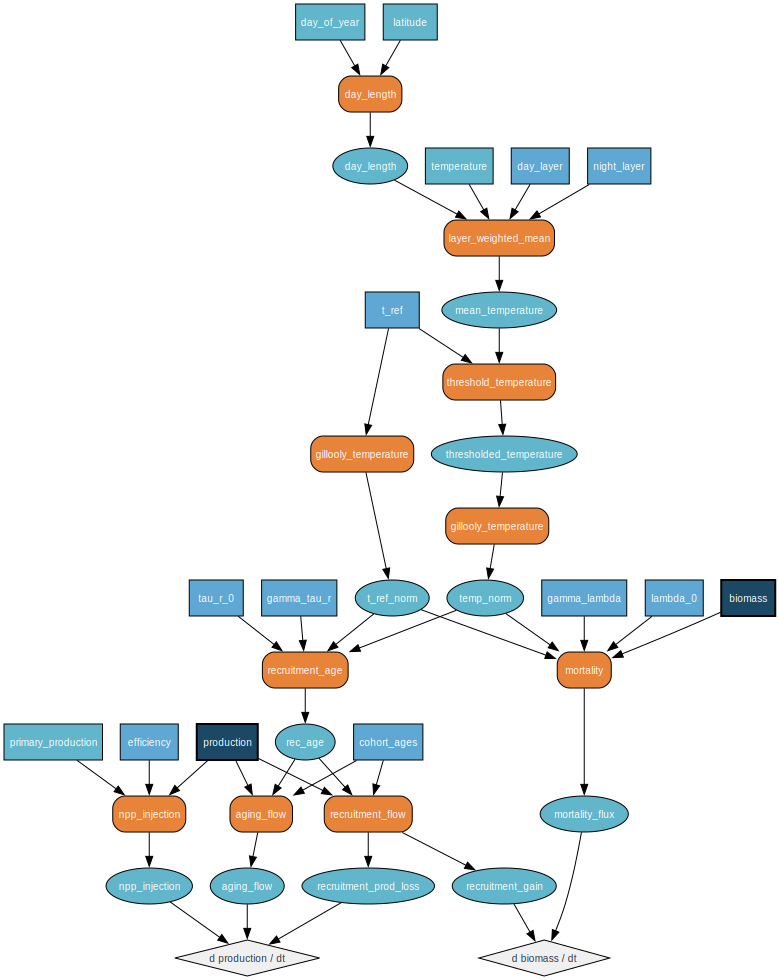

In [3]:
blueprint.to_graphviz()

## 2. Synthetic Forcings

For this example we generate simple seasonal forcings on a **1×1 grid**
(0-dimensional in space):

- **Temperature**: sinusoidal seasonal cycle (15 ± 5 °C)
- **NPP** (Net Primary Production): sinusoidal (1 ± 0.5 g/m²/day)
- **Latitude**: 30°N (controls day length)
- **Day of year**: from the date range

We simulate **2 years**: the first year serves as **spin-up** (the model
reaches a dynamic equilibrium), the second year is shown in the results.


In [4]:
# --- LMTL parameters (standard Seapodym values) ---
PARAMS = {
    "lambda_0": 1 / 150 / 86400,  # base mortality rate [1/s]
    "gamma_lambda": 0.15,  # thermal sensitivity of mortality [1/degC]
    "tau_r_0": 10.38 * 86400,  # base recruitment age [s]
    "gamma_tau_r": 0.11,  # thermal sensitivity of recruitment [1/degC]
    "t_ref": 0.0,  # reference temperature [degC]
    "efficiency": 0.1668,  # NPP transfer efficiency [dimensionless]
}

# --- Time setup ---
start_date = "2000-01-01"
end_date = "2002-01-01"  # 2 years (year 1 = spin-up)
dt = "3h"

start_pd = pd.to_datetime(start_date)
end_pd = pd.to_datetime(end_date)
n_days = (end_pd - start_pd).days + 5  # small margin for interpolation
dates = pd.date_range(start=start_pd, periods=n_days, freq="D")
day_of_year = dates.dayofyear.values

# --- Grid (1×1) ---
ny, nx = 1, 1
lat = np.arange(ny)
lon = np.arange(nx)

# --- Cohort ages ---
max_age_days = int(np.ceil(PARAMS["tau_r_0"] / 86400))
cohort_ages_sec = np.arange(0, max_age_days + 1) * 86400.0
n_cohorts = len(cohort_ages_sec)

print(f"Simulation: {start_date} → {end_date} (dt={dt})")
print(f"Grid: {ny}×{nx}, {n_cohorts} cohorts (max age = {max_age_days} days)")
print(f"Forcing dates: {len(dates)} days")

Simulation: 2000-01-01 → 2002-01-01 (dt=3h)
Grid: 1×1, 12 cohorts (max age = 11 days)
Forcing dates: 736 days


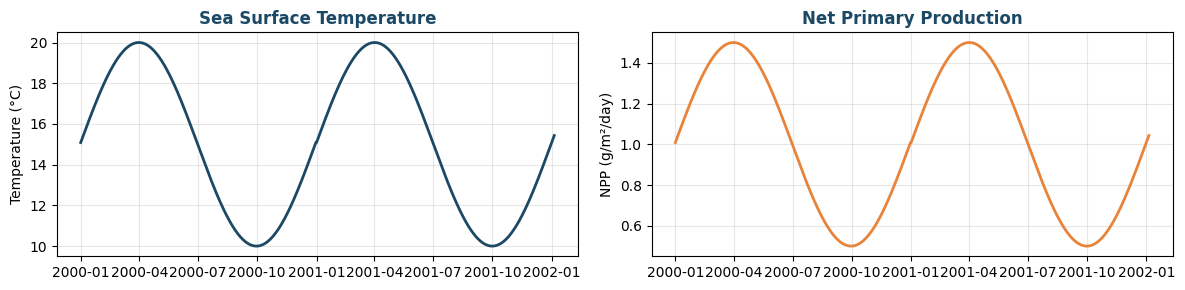

In [5]:
# --- Build forcing arrays ---
# Temperature: seasonal sine wave (15 ± 5 °C)
temp_c = 15.0 + 5.0 * np.sin(2 * np.pi * day_of_year / 365.0)
temp_4d = np.broadcast_to(temp_c[:, None, None, None], (len(dates), 1, ny, nx))

# NPP: seasonal sine wave (1 ± 0.5 g/m²/day → converted to g/m²/s)
npp_day = 1.0 + 0.5 * np.sin(2 * np.pi * day_of_year / 365.0)
npp_sec = npp_day / 86400.0
npp_3d = np.broadcast_to(npp_sec[:, None, None], (len(dates), ny, nx))

# Quick preview
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(dates, temp_c, color=PALETTE[0], linewidth=2)
ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Sea Surface Temperature", color="#1B4965", fontweight="bold")
ax1.grid(True, alpha=0.3)

ax2.plot(dates, npp_day, color=PALETTE[2], linewidth=2)
ax2.set_ylabel("NPP (g/m²/day)")
ax2.set_title("Net Primary Production", color="#1B4965", fontweight="bold")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 3. Configuration & Compilation

The **Config** provides concrete data for a Blueprint:

- `parameters` — model constants as `xr.DataArray`
- `forcings` — time-varying input data
- `initial_state` — starting values (zeros here: cold start)
- `execution` — time range, timestep, interpolation method


In [6]:
config = Config(
    parameters={
        "lambda_0": xr.DataArray([PARAMS["lambda_0"]], dims=["F"]),
        "gamma_lambda": xr.DataArray([PARAMS["gamma_lambda"]], dims=["F"]),
        "tau_r_0": xr.DataArray([PARAMS["tau_r_0"]], dims=["F"]),
        "gamma_tau_r": xr.DataArray([PARAMS["gamma_tau_r"]], dims=["F"]),
        "t_ref": xr.DataArray(PARAMS["t_ref"]),
        "efficiency": xr.DataArray([PARAMS["efficiency"]], dims=["F"]),
        "cohort_ages": xr.DataArray(cohort_ages_sec, dims=["C"]),
        "day_layer": xr.DataArray([0], dims=["F"]),
        "night_layer": xr.DataArray([0], dims=["F"]),
    },
    forcings={
        "latitude": xr.DataArray(np.full(ny, 30.0), dims=["Y"], coords={"Y": lat}),
        "temperature": xr.DataArray(
            temp_4d,
            dims=["T", "Z", "Y", "X"],
            coords={"T": dates, "Z": np.arange(1), "Y": lat, "X": lon},
        ),
        "primary_production": xr.DataArray(
            npp_3d,
            dims=["T", "Y", "X"],
            coords={"T": dates, "Y": lat, "X": lon},
        ),
        "day_of_year": xr.DataArray(
            day_of_year.astype(float),
            dims=["T"],
            coords={"T": dates},
        ),
    },
    initial_state={
        "biomass": xr.DataArray(
            np.zeros((1, ny, nx)),
            dims=["F", "Y", "X"],
            coords={"Y": lat, "X": lon},
        ),
        "production": xr.DataArray(
            np.zeros((1, n_cohorts, ny, nx)),
            dims=["F", "C", "Y", "X"],
            coords={"Y": lat, "X": lon},
        ),
    },
    execution={
        "time_start": start_date,
        "time_end": end_date,
        "dt": dt,
        "forcing_interpolation": "linear",
    },
)

print("Config created successfully.")
print(f"  Parameters: {list(config.parameters.keys())}")
print(f"  Forcings:   {list(config.forcings.keys())}")
print(f"  State:      {list(config.initial_state.keys())}")

Config created successfully.
  Parameters: ['lambda_0', 'gamma_lambda', 'tau_r_0', 'gamma_tau_r', 't_ref', 'efficiency', 'cohort_ages', 'day_layer', 'night_layer']
  Forcings:   ['latitude', 'temperature', 'primary_production', 'day_of_year']
  State:      ['biomass', 'production']


In [7]:
# Compile the model
t0 = time.time()
model = compile_model(blueprint, config)
compile_time = time.time() - t0

print(f"Compilation: {compile_time:.2f}s")
print(f"  Timesteps:  {model.n_timesteps}")
print(f"  dt:         {model.dt:.0f}s ({model.dt / 3600:.1f}h)")
print(f"  Shapes:     {model.shapes}")

Compilation: 0.05s
  Timesteps:  5848
  dt:         10800s (3.0h)
  Shapes:     {'T': 5848, 'Y': 1, 'Z': 1, 'X': 1, 'F': 1, 'C': 12}


## 4. Simulation

`simulate()` runs the compiled model using `jax.lax.scan`. It returns:

- `state` — final state (dict of JAX arrays)
- `outputs` — an `xr.Dataset` with all exported variables over time


In [8]:
t0 = time.time()
state, outputs = simulate(model, chunk_size=800, export_variables=["biomass", "production"])
sim_time = time.time() - t0

print(f"Simulation: {sim_time:.2f}s ({model.n_timesteps} timesteps)")
print("\nOutputs:")
print(outputs)

Simulation: 0.64s (5848 timesteps)

Outputs:
<xarray.Dataset> Size: 351kB
Dimensions:     (T: 5848, F: 1, Y: 1, X: 1, C: 12)
Coordinates:
  * T           (T) datetime64[us] 47kB 2000-01-01 ... 2001-12-31T21:00:00
  * Y           (Y) int64 8B 0
Dimensions without coordinates: F, X, C
Data variables:
    biomass     (T, F, Y, X) float32 23kB 0.0 1.336e-07 ... 2.991 2.991
    production  (T, F, C, Y, X) float32 281kB 0.02103 0.0 0.0 ... 0.0 0.0 0.0


## 5. Results

We display **year 2 only** (after spin-up). The ecosystem reaches a dynamic
equilibrium driven by the seasonal temperature and NPP forcings.


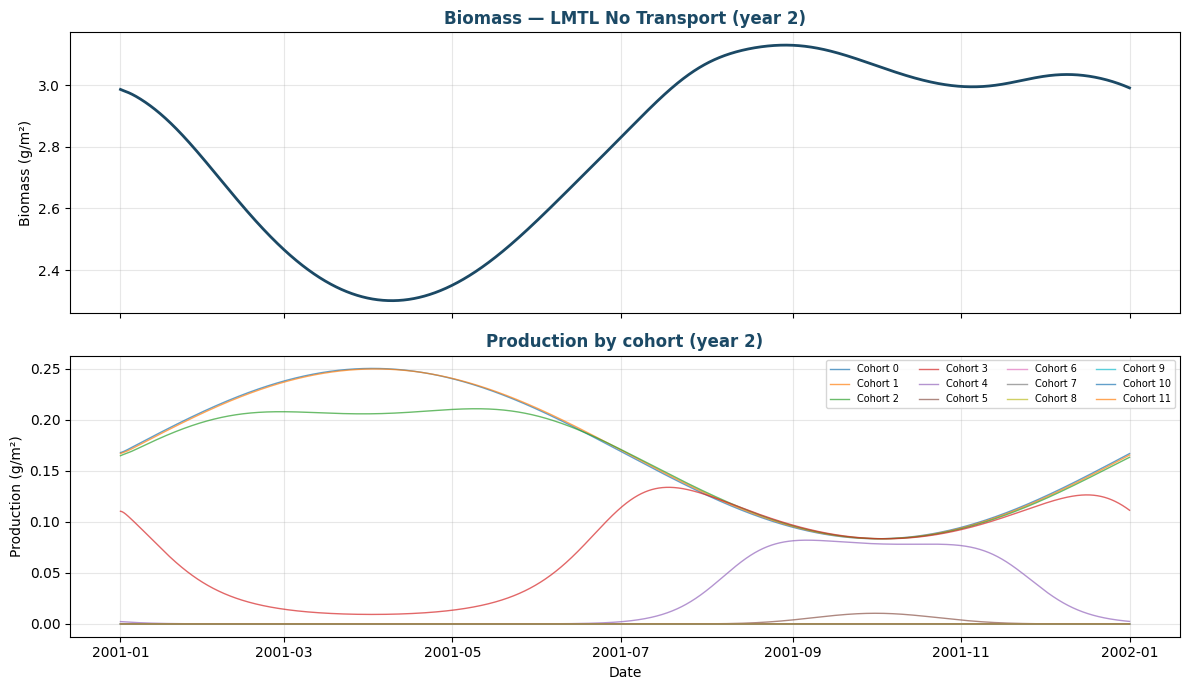

Year 2 biomass range: [2.3012, 3.1294] g/m²
Year 2 total production range: [0.4223, 0.7150] g/m²


In [9]:
# Extract year 2 data
biomass = outputs["biomass"]
production = outputs["production"]

time_coords = biomass.coords["T"].values
year2_mask = time_coords >= np.datetime64("2001-01-01")
year2_dates = time_coords[year2_mask]

# Biomass: squeeze spatial dims (1×1 grid)
biomass_ts = biomass.values[year2_mask, 0, 0, 0]  # (T, F, Y, X) → scalar

# Production: sum over cohorts, squeeze spatial dims
production_ts = production.values[year2_mask, 0, :, 0, 0]  # (T, F, C, Y, X) → (T, C)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Biomass ---
ax = axes[0]
ax.plot(year2_dates, biomass_ts, color=PALETTE[0], linewidth=2)
ax.set_ylabel("Biomass (g/m²)")
ax.set_title("Biomass — LMTL No Transport (year 2)", color="#1B4965", fontweight="bold")
ax.grid(True, alpha=0.3)

# --- Production per cohort ---
ax = axes[1]
for c in range(production_ts.shape[1]):
    ax.plot(year2_dates, production_ts[:, c], linewidth=1, alpha=0.7, label=f"Cohort {c}")
ax.set_ylabel("Production (g/m²)")
ax.set_xlabel("Date")
ax.set_title("Production by cohort (year 2)", color="#1B4965", fontweight="bold")
ax.legend(fontsize=7, ncol=4, loc="upper right")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"Year 2 biomass range: [{biomass_ts.min():.4f}, {biomass_ts.max():.4f}] g/m²")
print(
    f"Year 2 total production range: [{production_ts.sum(axis=1).min():.4f}, "
    f"{production_ts.sum(axis=1).max():.4f}] g/m²"
)

**Key takeaways:**

- A **Blueprint** declares the model topology (variables, process DAG, tendencies) without any data.
- A **Config** provides concrete parameter values, forcing arrays, and execution settings.
- `compile_model()` validates everything (units, dimensions, NaN) and builds a JAX-ready `CompiledModel`.
- `simulate()` runs the model and returns an `xr.Dataset` with labeled outputs.

**Next steps:**

- [Transport & Movement](../05_transport/) — Add spatial advection/diffusion.
- [Optimization](../03_optimization/) — Compare Gradient, GA & CMA-ES optimizers.
